<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:

!pip install -q gdown torch transformers accelerate bitsandbytes sentence-transformers faiss-cpu openpyxl datasets ragatouille umap-learn "langchain-core==0.3.79" "langchain-community==0.3.31"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 11.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 55.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 63.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 74.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 109.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.9 MB/s eta 0:00:00
   ━━━━━

In [2]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain.docstore.document import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel
from sklearn.feature_extraction.text import TfidfVectorizer

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)


/tmp/ipykernel_57/1794638983.py:17: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel


## Загрузка данных (4 балла)

In [3]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=0c184d68-6a27-49b8-9fc0-df093bbca905
To: /kaggle/working/file.csv
100%|██████████| 672M/672M [00:02<00:00, 268MB/s] 


In [4]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [5]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [6]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

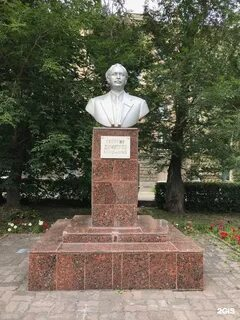

In [7]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [8]:

data['text'] = data['en_txt'].fillna('').astype(str)

tfidf = TfidfVectorizer(max_features=200, stop_words='english')
tfidf.fit(data['text'])
idf_vals = tfidf.idf_
mean_idf = np.mean(idf_vals)
rare_words = [word for word, idf in zip(tfidf.get_feature_names_out(), idf_vals) if idf > 2 * mean_idf]

trash_words = set(['selfie', 'meme', 'banner', 'advertisement', 'person', 'people', 'photo', 'screenshot'])
trash_mask = data['text'].str.lower().apply(lambda x: any(w in x for w in trash_words))
data_clean = data[~trash_mask].copy()

np.random.seed(42)
samples = []
for (city, name), group in data_clean.groupby(['City', 'Name']):
    n_samples = min(2, len(group))
    if n_samples == 0:
        continue
    group_sample = group.sample(n_samples, random_state=42)
    samples.append(group_sample)
    if sum(len(s) for s in samples) >= 100:
        break

df_sample = pd.concat(samples).reset_index(drop=True)
if len(df_sample) > 100:
    df_sample = df_sample.sample(100, random_state=42).reset_index(drop=True)

print(f"Отобрано {len(df_sample)} чистых уникальных объектов")

Отобрано 100 чистых уникальных объектов


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [9]:
documents = []
for _, row in df_sample.iterrows():
    content = "passage: " + row['text']
    metadata = {
        'name': row['Name'],
        'city': row['City'],
        'original_text': row['text'],
        'image': row['image']
    }
    documents.append(LangchainDocument(page_content=content, metadata=metadata))

embedding_model = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-small",
    model_kwargs={'device': 'cuda' if torch.cuda.is_available() else 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

vectorstore = FAISS.from_documents(documents, embedding_model)

class QueryPrefixRetriever:
    def __init__(self, vectorstore, search_kwargs=None):
        self.vectorstore = vectorstore
        self.search_kwargs = search_kwargs or {}
    def get_relevant_documents(self, query):
        prefixed_query = "query: " + query
        return self.vectorstore.similarity_search(prefixed_query, **self.search_kwargs)

retriever = QueryPrefixRetriever(vectorstore, search_kwargs={"k": 3})

query = "What is this place?"
docs = retriever.get_relevant_documents(query)
print(f"Найдено {len(docs)} релевантных документов")
for i, doc in enumerate(docs):
    print(f"{i+1}. {doc.metadata['name']} in {doc.metadata['city']}: {doc.page_content[:100]}...")

/tmp/ipykernel_57/3011387003.py:12: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Найдено 3 релевантных документов
1. Домовая церковь Елисаветы Феодоровны in Владимир: passage: arafed building with a clock on top of it and a door...
2. église arménienne de Vladimir in Владимир: passage: a view of a large white building with a clock tower in the middle of a park...
3. Владимирский академический областной драматический театр in Владимир: passage: arafed building with a large glass front and a clock on the front...


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [10]:

texts = [doc.metadata['original_text'] for doc in documents]
embeddings = np.array(embedding_model.embed_documents(["passage: " + t for t in texts]))

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(embeddings)

df_viz = df_sample[['Name', 'City']].copy()
df_viz['pca_x'] = pca_result[:, 0]
df_viz['pca_y'] = pca_result[:, 1]

fig_pca = px.scatter(df_viz, x='pca_x', y='pca_y', color='City', hover_data=['Name'],
                     title='PCA проекция эмбеддингов описаний')
fig_pca.show()

import umap
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_reducer.fit_transform(embeddings)

df_viz['umap_x'] = umap_result[:, 0]
df_viz['umap_y'] = umap_result[:, 1]

fig_umap = px.scatter(df_viz, x='umap_x', y='umap_y', color='City', hover_data=['Name'],
                      title='UMAP проекция эмбеддингов описаний')
fig_umap.show()

2026-05-02 17:50:36.948563: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777744237.150375      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777744237.215998      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777744237.723694      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777744237.723738      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777744237.723741      57 computation_placer.cc:177] computation placer alr

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

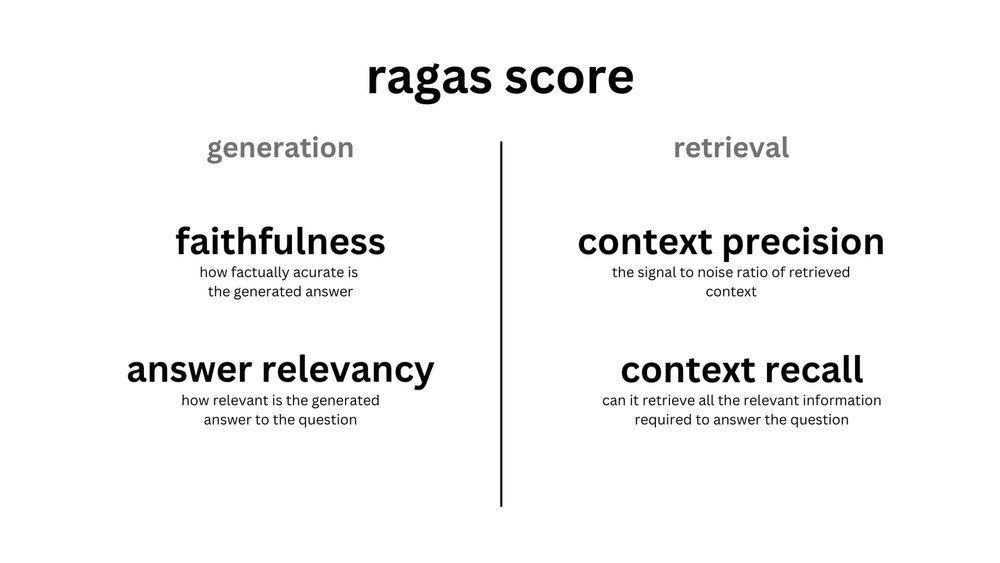

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [26]:
from sentence_transformers import SentenceTransformer, util

In [27]:
def data_preprocess(df_sample, retriever, generator):
    eval_data = []
    for _, row in df_sample.iterrows():
        question = f"Describe the landmark: {row['text'][:100]}"
        
        docs = retriever.get_relevant_documents(question)
        contexts = [doc.metadata['original_text'] for doc in docs[:3]]
        
        prompt = f"Question: {question}\nContext: {' '.join(contexts)}\nAnswer:"
        answer = generator(prompt, max_new_tokens=150, num_return_sequences=1)[0]['generated_text']
        
        ground_truth = row['text']
        
        eval_data.append({
            'question': question,
            'ground_truths': [ground_truth],
            'answer': answer,
            'contexts': contexts
        })
    return eval_data

In [28]:
def answer_relevancy(question: str, answer: str, model) -> float:
    q_emb = model.encode(question, convert_to_tensor=True)
    a_emb = model.encode(answer, convert_to_tensor=True)
    return util.cos_sim(q_emb, a_emb).item()

# Протестируйте ваш RAG (3 балла)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

Средняя Answer Relevancy по 100 образцам: 0.8301


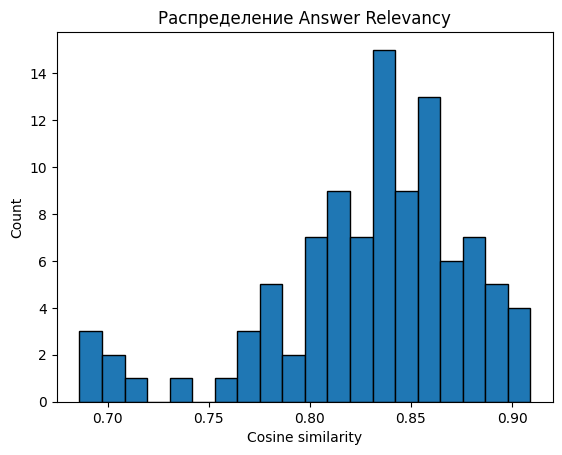

In [29]:
from transformers import pipeline

generator = pipeline("text-generation", model="google/flan-t5-base", device=0 if torch.cuda.is_available() else -1)

relevancy_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

eval_data = data_preprocess(df_sample, retriever, generator)

scores = []
for item in eval_data:
    score = answer_relevancy(item['question'], item['answer'], relevancy_model)
    scores.append(score)

avg_relevancy = np.mean(scores)
print(f"Средняя Answer Relevancy по {len(scores)} образцам: {avg_relevancy:.4f}")

plt.hist(scores, bins=20, edgecolor='black')
plt.title('Распределение Answer Relevancy')
plt.xlabel('Cosine similarity')
plt.ylabel('Count')
plt.show()

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [30]:

import re

def context_recall(ground_truth: str, contexts: List[str], model, threshold: float = 0.5) -> float:
    gt_sentences = re.split(r'(?<=[.!?])\s+', ground_truth)
    if not gt_sentences:
        return 0.0
    
    ctx_embs = model.encode(contexts, convert_to_tensor=True)
    
    found = 0
    for sent in gt_sentences:
        sent_emb = model.encode(sent, convert_to_tensor=True)
        sims = util.cos_sim(sent_emb, ctx_embs).squeeze()
        if sims.max().item() >= threshold:
            found += 1
    return found / len(gt_sentences)

print("Примеры Context Recall:")
for i, item in enumerate(eval_data[:5]):
    cr = context_recall(item['ground_truths'][0], item['contexts'], relevancy_model)
    print(f"{i+1}. {item['question']} -> Context Recall: {cr:.4f}")

Примеры Context Recall:
1. Describe the landmark: arafed man in a suit holding a newspaper in front of a bookcase -> Context Recall: 1.0000
2. Describe the landmark: a close up of a tank with a picture of a man on it -> Context Recall: 1.0000
3. Describe the landmark: a close up of a coin with a picture of a building on it -> Context Recall: 1.0000
4. Describe the landmark: a close up of a nativity scene in front of a house -> Context Recall: 1.0000
5. Describe the landmark: a view of a large white building with a clock tower in the middle of a park -> Context Recall: 1.0000
